# Clustering of Cropped Images Using CNN-AE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Optional

import tensorflow as tf
from tensorflow.keras import layers, models
import random

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1) Import Curated Cropped Images Dataset

In [2]:
files = "../Images_data/cropped_images_rotated.npz"

# Load data
data = np.load(files, allow_pickle=True)
images = data["images"] 
names = data["names"].tolist()

print(f"Image shape: {images.shape}")

Image shape: (55896, 32, 32)


# 2) CNN-AE (Rotated Images Input):

In [3]:
X = np.expand_dims(images, axis=-1)
print(f"Input shape: {X.shape}")

Input shape: (55896, 32, 32, 1)


In [4]:
seed = 4224

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

input_shape = X.shape[1:] 
latent_dim = 84

# Encoder
encoder = models.Sequential([
    layers.Input(shape=input_shape),
    
    layers.Conv2D(6, (5,5), padding='valid'), 
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

    layers.Conv2D(16, (5,5), padding='valid'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),

    layers.Conv2D(120, (5,5), padding='valid'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Flatten(),
    layers.Dense(latent_dim),
    layers.Activation('relu', name="latent_features")
])
encoder.summary()

# Decoder
decoder = models.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(120),
    layers.Activation('relu'),
    layers.Reshape((1,1,120)),

    layers.Conv2DTranspose(16, (5,5), padding='valid'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.UpSampling2D((2,2)),

    layers.Conv2DTranspose(6, (5,5), padding='valid'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.UpSampling2D((2,2)),

    layers.Conv2DTranspose(1, (5,5), padding='valid'),
    layers.Activation('sigmoid'),
])
decoder.summary()


# Autoencoder
autoencoder = models.Sequential([encoder, decoder])
autoencoder.compile(optimizer="adam", loss="mse")

# -----------------------------
# Train Autoencoder
# -----------------------------

out=autoencoder.fit(
    X, X, epochs=300, batch_size=128, validation_split=0.2
)

# -----------------------------
# Extract Latent Features
# -----------------------------
latent_features = encoder.predict(X)
print("Latent feature shape:", latent_features.shape)  # (N, 84)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 batch_normalization (Batch  (None, 28, 28, 6)         24        
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 28, 6)         0         
                                                                 
 average_pooling2d (Average  (None, 14, 14, 6)         0         
 Pooling2D)                                                      
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 batch_normalization_1 (Bat  (None, 10, 10, 16)        6

I0000 00:00:1776220358.032091 1341492 service.cc:145] XLA service 0x1473e64402d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776220358.032121 1341492 service.cc:153]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1776220358.151179 1341492 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/350 [==============================] - 24s 17ms/step - loss: 0.0497 - val_loss: 0.0148
Epoch 2/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0099 - val_loss: 0.0097
Epoch 3/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0075 - val_loss: 0.0084
Epoch 4/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0064 - val_loss: 0.0069
Epoch 5/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0058 - val_loss: 0.0075
Epoch 6/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0054 - val_loss: 0.0062
Epoch 7/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0049 - val_loss: 0.0060
Epoch 8/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0048 - val_loss: 0.0053
Epoch 9/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0046 - val_loss: 0.0055
Epoch 10/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0046 - val_los

350/350 [==============================] - 4s 13ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 81/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 82/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 83/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 84/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 85/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 86/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 87/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 88/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 89/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0022 - 

350/350 [==============================] - 4s 13ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 160/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 161/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 162/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 163/300
350/350 [==============================] - 5s 13ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 164/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 165/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 166/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 167/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 168/300
350/350 [==============================] - 4s 13ms/step - loss: 

Epoch 238/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 239/300
350/350 [==============================] - 4s 13ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 240/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 241/300
350/350 [==============================] - 4s 11ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 242/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 243/300
350/350 [==============================] - 4s 11ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 244/300
350/350 [==============================] - 4s 12ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 245/300
350/350 [==============================] - 4s 11ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 246/300
350/350 [==============================] - 4s 11ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 247/300
350/350 [==============================] - 4s 12ms

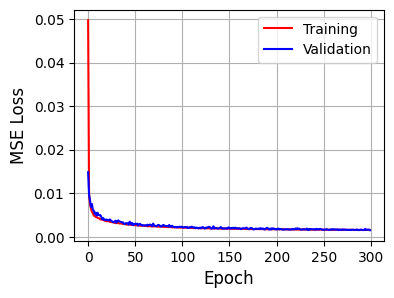

In [5]:
fig = plt.figure(figsize=(4,3))
plt.plot(out.history['loss'], color= 'red', lw=1.5, label='Training')
plt.plot(out.history['val_loss'], color= 'blue', lw=1.5, label='Validation')
plt.legend(loc='upper right', fontsize=12)
plt.xlabel('Epoch', fontsize = 12)
plt.ylabel('MSE Loss', fontsize = 12)
#plt.title('Autoencoder Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()